# **Bloque 1. Código**

**1.1 Importamos paquetes necesarios**

In [ ]:
!pip install onedrivedownloader
!pip install optuna
!pip install --upgrade hyperopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 602.4/602.4 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.3/491.3 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.0/203.0 kB 14.1 MB/s eta 0:00:00


In [ ]:
# Leer archivos de onedrive y descargar
from onedrivedownloader import download
from google.colab import files

# Paquetes típicos
import numpy as np
import pandas as pd

# Para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Para la preparación de los datos
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif

# Para encontrar parámetros óptimos
import optuna

# Modelos de ML
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, mean_absolute_error, f1_score
from sklearn.naive_bayes import GaussianNB

from sklearn.datasets import make_classification

**1.2 Descargar archivo original**

In [ ]:
url = 'https://universidadfv-my.sharepoint.com/:x:/g/personal/alberto_desantos_ufv_es/EYyohJiyYgdEgZQBuVAATOYBz_lWRPYAI5POI_E-YLiklA?rtime=HeKBzBRM3Ug'

download(url = url, filename = 'archivo.csv', force_download=True, clean=True)

100%|██████████| 193M/193M [00:05<00:00, 35.8MiB/s]


'archivo.csv'

In [ ]:
raw_data = pd.read_csv('archivo.csv')

**1.3 Limpieza de datos**

In [ ]:
raw_data.head()

,Unnamed: 0,LOC_PerderVisitDiff3_max,LOC_PerderVisitDiff3_min,LOC_PerderVisitDiff3_median,LOC_PerderVisitDiff2_max,LOC_PerderVisitDiff2_min,LOC_PerderVisitDiff2_median,LOC_PerderLocalDiff3_max,LOC_PerderLocalDiff3_min,LOC_PerderLocalDiff3_median,...,timestamp,goles_local,goles_visit,raw_odd_gana_local,raw_odd_gana_visit,raw_odd_empatar,equipo_local,equipo_visit,pais,timestamp_day
0,0,0,0,0,0,0,0,0,0,0,...,2000-04-29 18:00:00+00:00,0.0,1.0,0.0,0.0,0.0,Rosenborg,Molde,NOR,2000-04-29
1,1,0,0,0,0,0,0,0,0,0,...,2000-04-29 18:00:00+00:00,0.0,2.0,0.0,0.0,0.0,Start,Brann,NOR,2000-04-29
2,0,0,0,0,0,0,0,0,0,0,...,2000-04-30 18:00:00+00:00,4.0,1.0,0.0,0.0,0.0,Bodoe/Glimt,Moss FK,NOR,2000-04-30
3,1,0,0,0,0,0,0,0,0,0,...,2000-04-30 18:00:00+00:00,2.0,1.0,0.0,0.0,0.0,Odd,Lillestroem,NOR,2000-04-30
4,2,0,0,0,0,0,0,0,0,0,...,2000-04-30 18:00:00+00:00,2.0,1.0,0.0,0.0,0.0,Tromsoe,Stabaek,NOR,2000-04-30


**1.3.1 Datos nulos**<p>
Una primera vista del archivo en *Excel* es suficiente para ver que muchos datos se han recogido de forma errónea. Por ejemplo, son miles las filas dónde las cuotas de las casas de apuestas son nulas. Estas filas lógicamente no caben en el entrenamiento de un modelo que trata de ganar el máximo dinero posible apostando.

In [ ]:
# Filtrar las filas donde "raw_odd_gana_visit" NO sea 0.0
filtered_data_1 = raw_data[raw_data['raw_odd_gana_local'] != 0.0]

filtered_data_1.head()

,Unnamed: 0,LOC_PerderVisitDiff3_max,LOC_PerderVisitDiff3_min,LOC_PerderVisitDiff3_median,LOC_PerderVisitDiff2_max,LOC_PerderVisitDiff2_min,LOC_PerderVisitDiff2_median,LOC_PerderLocalDiff3_max,LOC_PerderLocalDiff3_min,LOC_PerderLocalDiff3_median,...,timestamp,goles_local,goles_visit,raw_odd_gana_local,raw_odd_gana_visit,raw_odd_empatar,equipo_local,equipo_visit,pais,timestamp_day
6208,0,0,0,0,3,3,3,3,3,3,...,2002-10-28 20:00:00+00:00,1.0,1.0,1.70,3.65,3.50,Louvieroise,Mechelen,BEL,2002-10-28
6209,1,1,1,1,1,1,1,1,1,1,...,2002-10-28 20:00:00+00:00,2.0,1.0,1.55,4.35,3.60,Lokeren,Royal Antwerp,BEL,2002-10-28
6210,0,0,0,0,1,1,1,2,2,2,...,2002-10-28 21:00:00+00:00,1.0,1.0,2.09,2.85,3.15,Bolton,Sunderland,ENG,2002-10-28
6211,0,0,0,0,0,0,0,0,0,0,...,2002-11-01 20:00:00+00:00,5.0,1.0,2.20,2.55,3.31,Zwolle,Alkmaar,NLD,2002-11-01
6212,0,0,0,0,0,0,0,0,0,0,...,2002-11-02 19:30:00+00:00,0.0,0.0,2.24,2.50,3.30,Excelsior,Nijmegen,NLD,2002-11-02


**1.3.2 Columnas a posteriori**<p>
Los datos del archivo se dividen en aquellos previos al partido y aquellos que se recogen después. Puesto que la predicción consiste en inferir sobre el futuro basándose en la información del pasado, todas las variables a posteriori las eliminamos, así como aquellas que no aporten información alguna. Eliminamos también la columna *resultado_target* puesto que es la predicción de otro modelo que nosotros ni conocemos ni poseemos.

In [ ]:
# Lista de columnas a eliminar
columns_to_drop = ["goles_local", "goles_visit", "resultado_target"]

# También eliminar cualquier columna que contenga "Unnamed"
columns_to_drop.extend([col for col in filtered_data_1.columns if "Unnamed" in col])

# Eliminar las columnas especificadas
filtered_data_2 = filtered_data_1.drop(columns=columns_to_drop)

# Mostrar las primeras filas
filtered_data_2.head()

,LOC_PerderVisitDiff3_max,LOC_PerderVisitDiff3_min,LOC_PerderVisitDiff3_median,LOC_PerderVisitDiff2_max,LOC_PerderVisitDiff2_min,LOC_PerderVisitDiff2_median,LOC_PerderLocalDiff3_max,LOC_PerderLocalDiff3_min,LOC_PerderLocalDiff3_median,LOC_PerderLocalDiff2_max,...,jornada,periodo,timestamp,raw_odd_gana_local,raw_odd_gana_visit,raw_odd_empatar,equipo_local,equipo_visit,pais,timestamp_day
6208,0,0,0,3,3,3,3,3,3,1,...,10,nt,2002-10-28 20:00:00+00:00,1.70,3.65,3.50,Louvieroise,Mechelen,BEL,2002-10-28
6209,1,1,1,1,1,1,1,1,1,1,...,10,nt,2002-10-28 20:00:00+00:00,1.55,4.35,3.60,Lokeren,Royal Antwerp,BEL,2002-10-28
6210,0,0,0,1,1,1,2,2,2,1,...,11,nt,2002-10-28 21:00:00+00:00,2.09,2.85,3.15,Bolton,Sunderland,ENG,2002-10-28
6211,0,0,0,0,0,0,0,0,0,0,...,3,nt,2002-11-01 20:00:00+00:00,2.20,2.55,3.31,Zwolle,Alkmaar,NLD,2002-11-01
6212,0,0,0,0,0,0,0,0,0,0,...,3,nt,2002-11-02 19:30:00+00:00,2.24,2.50,3.30,Excelsior,Nijmegen,NLD,2002-11-02


**1.3.3 Objetos en los datos**<p>
En esta sección, eliminamos todas las variables categóricas, ya que no son compatibles con el modelo de *Machine Learning*. Además, estandarizamos la representación de los empates, reemplazando la "X" por el valor numérico 0 para garantizar la coherencia en el procesamiento de los datos.

In [ ]:
# Reemplazar valores en 'resultado'
filtered_data_2['resultado'] = filtered_data_2['resultado'].replace({'X': 0}).astype(int)

filtered_data_3 = filtered_data_2.drop(columns=[col for col in filtered_data_2.columns if filtered_data_2[col].dtype == "object"])

# Mostrar primeras filas
filtered_data_3.head()

,LOC_PerderVisitDiff3_max,LOC_PerderVisitDiff3_min,LOC_PerderVisitDiff3_median,LOC_PerderVisitDiff2_max,LOC_PerderVisitDiff2_min,LOC_PerderVisitDiff2_median,LOC_PerderLocalDiff3_max,LOC_PerderLocalDiff3_min,LOC_PerderLocalDiff3_median,LOC_PerderLocalDiff2_max,...,VIS_NumPartidosMarcandoLocal,VIS_GolesContraVisit,VIS_GolesFavorVisit,VIS_GolesContraLocal,VIS_GolesFavorLocal,resultado,jornada,raw_odd_gana_local,raw_odd_gana_visit,raw_odd_empatar
6208,0,0,0,3,3,3,3,3,3,1,...,3,15,4,7,6,0,10,1.70,3.65,3.50
6209,1,1,1,1,1,1,1,1,1,1,...,5,8,5,11,10,1,10,1.55,4.35,3.60
6210,0,0,0,1,1,1,2,2,2,1,...,2,8,2,6,2,0,11,2.09,2.85,3.15
6211,0,0,0,0,0,0,0,0,0,0,...,4,10,6,13,9,1,3,2.20,2.55,3.31
6212,0,0,0,0,0,0,0,0,0,0,...,4,4,4,11,10,0,3,2.24,2.50,3.30


**1.3.4 Variables relevantes**<p>
No todas las variables influyen de igual forma en el resultado. Por ello, estudiamos qué variables son relevantes y eliminamos aquellas, por el contrario, no aportan información al modelo. Tomamos como valores significativos 0.05 y 0.01. Por encima de 0.05, la variable tiene una alta correlación con el resultado. Entre 0.01 y 0.05 la variable posee una correlación media con el resultado; y por debajo de 0.01, la variable no influye en el resultado.

In [ ]:
# Calcular MI_Score
X = filtered_data_3.drop(columns=["resultado"])
y = filtered_data_3["resultado"]
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({"Columna": X.columns, "MI_Score": mi_scores})

# Ordenar y mostrar
mi_df = mi_df.sort_values("MI_Score", ascending=False)
print(mi_df.head(20))  # Top 20 para inspeccionar

# Establecer los umbrales
threshold_1 = 0.05
threshold_2 = 0.01
very_relevant_columns = mi_df[mi_df["MI_Score"] >= threshold_1]["Columna"].tolist()
medium_relevant_columns = mi_df[(mi_df["MI_Score"] < threshold_1) & (mi_df["MI_Score"] >= threshold_2)]["Columna"].tolist()
print(f"Columnas con MI_Score >= {threshold_1}:", len(very_relevant_columns))
print(very_relevant_columns)
print(f"Columnas con {threshold_2} <= MI_Score < {threshold_1}:", len(medium_relevant_columns))
print(medium_relevant_columns)

                                      Columna  MI_Score
451                        raw_odd_gana_local  0.107407
452                        raw_odd_gana_visit  0.107056
443                 VIS_PosicionClasificacion  0.030996
437                      VIS_PosicionMasComun  0.027342
387                 LOC_PosicionClasificacion  0.024665
424               VIS_MaxRachaPartidosGanados  0.023606
294        VIS_NumPartidosGanadosVisit_median  0.023414
439                       VIS_PosicionMasAlta  0.022244
267  VIS_MaxRachaPartidosPerdidosVisit_median  0.021531
249      VIS_MaxRachaPartidosSinPerder_median  0.021527
368               LOC_MaxRachaPartidosGanados  0.021488
108      LOC_MaxRachaPartidosGanadosLocal_max  0.021407
181                   VIS_GanarVisitDiff3_max  0.021181
186                VIS_GanarVisitDiff2_median  0.020874
252       VIS_MaxRachaPartidosSinGanar_median  0.020598
292           VIS_NumPartidosGanadosVisit_max  0.020460
381                      LOC_PosicionMasComun  0

**1.4 Definición entrenamiento**

**1.4.1 Datos entrenamiento**<p>
Como hemos mencionado anteriormente en la sección 1.3.4, para el entrenamiento empleamos únicamente las variables con una correlación con el resultado de 0.01 o superior.

In [ ]:
X = filtered_data_3[very_relevant_columns + medium_relevant_columns]
y = filtered_data_3["resultado"]

**1.4.2 Normalización de los datos**<p>
Los datos del entrenamiento los normalizamos con *RobustScaler*, que elimina las medianas y escala los datos acorde al rango intercuartílico.

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Scale the cleaned data
scaler = RobustScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

**1.4.3 Pesos de las clases**<p>
Nuestro *dataframe* de entrada presenta un gran desajuste en las clases. Mientras que casi el 45% de los partidos resultan en la victoria del equipo local, apenas el 25% corresponden a un empate. Para solucionar este problema, definimos los pesos que se le asigna a cada clase (0, 1 o 2).

In [ ]:
# Count occurrences of 0, 1, and 2
counts = filtered_data_3["resultado"].value_counts()
n_cero = counts.get(0, 0)
n_uno = counts.get(1, 0)
n_dos = counts.get(2, 0)

# Total number of samples
total_counts = len(filtered_data_3)

# Calculate class weights as scalars
class_weights = {
    0: float(total_counts) / n_cero if n_cero > 0 else 0,
    1: float(total_counts) / n_uno if n_uno > 0 else 0,
    2: float(total_counts) / n_dos if n_dos > 0 else 0
}

print(class_weights)

{0: 3.964249712825562, 1: 2.2265042791310075, 2: 3.348839512040558}


**1.4.4 Visualización del resultado**<p>
Dos son los objetos esenciales para analizar la precisión de un modelo de ML: el reporte de clasificación y la matriz de confusión. Definimos entonces una función para mostrar ambas métricas.

In [ ]:
def analisis_entrenamiento(n):
  Y_pred = n.predict(X_test_scaled)

  from sklearn.metrics import confusion_matrix, classification_report
  cm = confusion_matrix(y_test, Y_pred)

  sns.heatmap(cm, annot=True,fmt='d')

  print(classification_report(y_test, Y_pred))

**1.5 Selección del modelo y optimización de parámetros**<p>
Tras una intensiva búsqueda del mejor modelo posible, decidimos quedarnos con el modelo SVC lineal por sus altos resultados. Mencionamos algunos de los modelos que hemos probado: *Random Forest*, *XGBoost*, *Decision Tree*, *Gaussian Naive Bayesian*, *Bernoulli Naive Bayesian* y *KNN*.

In [ ]:
def objective_svc(trial):
    # Suggest hyperparameters
    C = trial.suggest_float('C', 1e-1, 1e1, log=True)  # Updated to suggest_float

    # Define the SVC model
    model = LinearSVC(
        C=C,
        class_weight=class_weights  # Assuming class_weights is defined elsewhere
    )

    # Perform cross-validation
    scores = cross_val_score(model, X_train_scaled, y_train, cv=2, scoring='accuracy')
    return np.mean(scores)

# Create and run the study
study = optuna.create_study(direction='maximize')
study.optimize(objective_svc, n_trials=10)

# Print best hyperparameters
best_params = study.best_params
print("Best hyperparameters:", best_params)

[I 2025-03-16 16:44:19,900] A new study created in memory with name: no-name-e445312a-0c6e-4e62-a8d2-333fc799a478
[I 2025-03-16 16:45:29,702] Trial 0 finished with value: 0.5233216540264041 and parameters: {'C': 6.1969069135186015}. Best is trial 0 with value: 0.5233216540264041.
[I 2025-03-16 16:46:38,138] Trial 1 finished with value: 0.5232920861607605 and parameters: {'C': 2.335993975510874}. Best is trial 0 with value: 0.5233216540264041.
[I 2025-03-16 16:47:48,414] Trial 2 finished with value: 0.523255126328706 and parameters: {'C': 4.627336023143505}. Best is trial 0 with value: 0.5233216540264041.
[I 2025-03-16 16:48:56,747] Trial 3 finished with value: 0.5232846941943496 and parameters: {'C': 6.677523805595529}. Best is trial 0 with value: 0.5233216540264041.
[I 2025-03-16 16:50:05,600] Trial 4 finished with value: 0.5232699102615277 and parameters: {'C': 6.297328882974731}. Best is trial 0 with value: 0.5233216540264041.
[I 2025-03-16 16:51:19,296] Trial 5 finished with value:

Best hyperparameters: {'C': 6.1969069135186015}


              precision    recall  f1-score   support

           0       0.33      0.18      0.23      8563
           1       0.60      0.69      0.64     15144
           2       0.50      0.57      0.53     10114

    accuracy                           0.52     33821
   macro avg       0.47      0.48      0.47     33821
weighted avg       0.50      0.52      0.50     33821



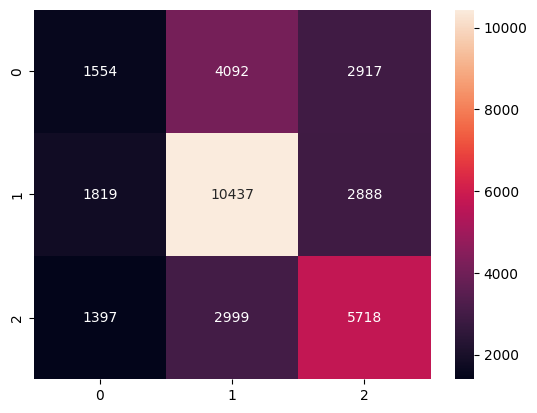

In [ ]:
model_svc = LinearSVC(class_weight=class_weights, C=best_params["C"])
model_svc.fit(X_train_scaled, y_train)
analisis_entrenamiento(model_svc)

**1.6 Ingresos**

**1.6.1 Matriz de apuesta**<p>
Para calcular los ingresos, creamos primero una matriz a partir del resultado de los partidos, la predicción de nuestro modelo, y las cuotas de las casas de apuestas. Con esta nueva matriz de 5 variables, tenemos las herramientas para hallar nuestros ingresos.

In [ ]:
dinero = X_test[["raw_odd_empatar", "raw_odd_gana_local", "raw_odd_gana_visit"]]
valor_real = pd.DataFrame(y_test)
valor_pred = pd.DataFrame(model_svc.predict(X_test_scaled), columns=["apuesta"])
valor_pred.index = valor_real.index  # Align indices

In [ ]:
beneficio = pd.concat([valor_real, valor_pred, dinero], axis=1)
beneficio.head()

,resultado,apuesta,raw_odd_empatar,raw_odd_gana_local,raw_odd_gana_visit
49687,0,2,3.28,2.28,2.71
174676,2,2,4.48,4.74,1.65
59631,0,1,3.19,2.36,2.91
63105,0,1,3.34,1.87,4.07
117619,0,2,2.92,3.18,2.61


**1.6.2 ¿Cuándo apostar?**<p>
Decdimos apostar en todos los partidos, aunque diferentes estrategias se pueden tomar para tratar de mejorar la eficiencia de las apuestas.

In [ ]:
res_apuesta = {0: "raw_odd_empatar",
               1: "raw_odd_gana_local",
               2: "raw_odd_gana_visit"}
ingresos = 0
aciertos = 0
fallos = 0

for _, row in beneficio.iterrows():
    apuesta = row["apuesta"]
    resultado = row["resultado"]
    if row[res_apuesta[apuesta]] > 1:
        if resultado == apuesta:
            ingresos += (row[res_apuesta[apuesta]] - 1)
            aciertos += 1
        else:
            ingresos -= 1
            fallos += 1
    else:
        pass
print(f'Ingresos de {ingresos:.2f}€ en {aciertos + fallos} partidos apostados.')
print(f'Tasa de acierto: {(aciertos/(aciertos + fallos))*100:.2f}%')
print(f'Ingresos por partido: {(ingresos/(aciertos+fallos)):.2f}€')

Ingresos de -1329.12€ en 33819 partidos apostados.
Tasa de acierto: 52.36%
Ingresos por partido: -0.04€


# **Bloque 2. Resultados y Discusión**

**2.1 Métricas del Modelo**<p>
El rendimiento de clasificación del modelo, detallado en la matriz de confusión y las métricas asociadas, ofrece una comprensión detallada de sus capacidades predictivas. La matriz de confusión muestra la distribución de etiquetas predichas frente a las reales, donde los elementos de la diagonal principal indican predicciones correctas. El modelo destaca en la clase 1, con 10,437 verdaderos positivos, mientras que las clases 0 y 2 presentan un menor número de predicciones correctas, con 1,554 y 5,718 verdaderos positivos, respectivamente. Esto se debe a un desbalance de clases. Los elementos fuera de la diagonal, como los 4,092 falsos positivos de la clase 1 predichos como clase 0 y los 2,888 falsos positivos de la clase 2 predichos como clase 1, evidencian áreas donde el modelo tiene problemas de confusión entre clases, especialmente entre las clases 1 y 2.<p>

Las métricas de clasificación complementan el análisis de la matriz de confusión y aportan mayor claridad sobre la eficacia del modelo. Las puntuaciones de precisión son 0.33, 0.60 y 0.50 para las clases 0, 1 y 2, respectivamente, lo que indica que las predicciones de la clase 1 son relativamente confiables, mientras que las de la clase 0 lo son menos. Los valores de sensibilidad (recall) de 0.18, 0.69 y 0.57 para las mismas clases sugieren que el modelo identifica una proporción moderada de instancias reales de las clases 1 y 2, pero tiene un desempeño pobre en la clase 0. Las puntuaciones F1, que equilibran precisión y sensibilidad, son 0.23, 0.64 y 0.53, lo que refuerza que la clase 1 es la mejor predicha.

La baja precisión del modelo para la clase 0 destaca la necesidad de optimizar el modelo, posiblemente mediante técnicas como el re-muestreo de datos o el ajuste de los pesos de las clases, para incrementar su robustez en la clasificación.

**2.2 Resultado Económico**<p>
Los resultados obtenidos tras la implementación del modelo basado en *SVC* con optimización de hiperparámetros mediante *Optuna* muestran un desempeño mixto en términos de precisión predictiva y rentabilidad económica. El modelo alcanzó una tasa de acierto del 52.36% sobre un total de 33,819 partidos apostados, lo que indica una capacidad moderada para predecir correctamente los resultados (empate: 0, victoria local: 1, victoria visitante: 2). Sin embargo, a pesar de esta tasa de acierto superior al 50%, el ingreso neto fue negativo, con una pérdida de -1,329.12€, equivalente a -0.04€ por partido apostado. Este resultado subraya una desconexión entre la precisión del modelo y su capacidad para generar beneficios económicos, un aspecto crítico dado el objetivo de maximizar ganancias en apuestas.<p>

La matriz de apuesta creada (beneficio) permitió evaluar el impacto de las cuotas en los ingresos. Al apostar en todos los partidos con cuotas superiores a 1, se observa que las pérdidas son significativas, lo que sugiere que la estrategia de apostar indiscriminadamente no es viable. Este hallazgo se alinea con las observaciones del apartado "Beneficio" (3.3), donde se nota que restringir las apuestas a cuotas más altas (ej., >2€) reduce las pérdidas (-600€ frente a -1300), aunque a costa de una menor tasa de acierto (38% vs. 52%). Esta relación inversa entre cuotas altas y precisión refleja la dificultad inherente de predecir partidos con mayor incertidumbre, donde las casas de apuestas asignan probabilidades más equilibradas o arriesgadas.<p>

Un análisis adicional revela que el modelo tiende a generalizar en exceso debido a la diversidad de los datos de entrenamiento, que incluyen tanto partidos predecibles (cuotas cercanas a 1) como altamente inciertos (cuotas elevadas y equilibradas). Esto limita su capacidad para especializarse en subconjuntos específicos de partidos, como aquellos con cuotas altas, donde el potencial de ganancia es mayor pero la predicción es más compleja. Además, la incorporación de métricas como el ELO (sección 3.1) no mejoró sustancialmente los resultados, lo que indica que variables tradicionales de rendimiento relativo no son suficientes para capturar la dinámica completa de los partidos de fútbol.

**2.3 Resumen General**

En resumen, aunque el modelo logra una tasa de acierto aceptable, su aplicación práctica para generar ingresos positivos requiere ajustes estratégicos. La discusión apunta a la necesidad de equilibrar precisión y rentabilidad, sugiriendo que un enfoque más selectivo en las apuestas o una reestructuración del entrenamiento podrían mitigar las pérdidas observadas.

# **Bloque 3. Aprendizajes**

**3.1 ELO**<p>
El sistema ELO es un método de puntuación ampliamente utilizado en el *gaming* competitivo para evaluar la habilidad relativa de los jugadores. En el contexto del fútbol, la web *ClubElo* proporciona esta métrica para prácticamente todos los equipos europeos desde hace más de 30 años y cuenta con una API que permite consultar el ELO de un equipo en cualquier momento histórico. Por ello, consideré interesante reemplazar las columnas *equipo_local* y *equipo_visitante* por el ELO de cada equipo el día anterior al partido.<p>
Tras horas de extracción de datos, obtuve un conjunto de 35.000 filas, cinco veces más pequeño que el original. Sin embargo, pese al esfuerzo y la lógica detrás de la idea, los resultados fueron decepcionantes. Solo la columna *equipo_local* mostró una ligera correlación con el resultado del partido, y dicha relación era mínima. Aun así, ejecuté el modelo y, aunque el *net income* fue significativamente mayor (-350€), esto se logró apostando en apenas 7.000 partidos con una tasa de acierto del 46%.<p>
Esto confirma una realidad evidente en el fútbol: no basta con identificar al favorito para hacer predicciones precisas. La diferencia entre los equipos debe ser extraordinaria para que el ELO sea un indicador determinante. En la mayoría de los casos, sigue siendo una referencia útil, pero insuficiente. Existen muchas más variables que influyen en el resultado de un partido.

**3.2 Modelo Recursivo**<p>

La columna *resultado_target* proviene de un modelo diseñado para predecir el resultado de un partido. Al utilizar esta columna en el entrenamiento de nuestro modelo, es posible alcanzar un *F1-score macro* de hasta un 77%, un valor excepcional que, sin duda, generaría resultados positivos.

Con esto en mente, consideré una estrategia iterativa: entrenar el modelo una primera vez, utilizar sus predicciones como entrada para un segundo modelo y repetir el proceso sucesivamente. Sin embargo, aunque esta idea parecía prometedora, en la práctica resulta contraproducente. Dado que el modelo inicial tiene una tasa de acierto del 53%, basar el entrenamiento en sus predicciones conduce a una disminución en la precisión, reduciendo el acierto final al 45%.

**3.3 Beneficio**<p>
El *net income* aumenta al apostar en partidos con cuotas más elevadas. Si se apuesta en todos los encuentros con cuotas superiores a 1€, la pérdida aproximada es de 1300. En contraste, al restringir las apuestas a partidos con cuotas superiores a 2€, la pérdida se reduce a 600€. Sin embargo, esta relación positiva con el *net income* se asocia a una disminución en la tasa de acierto: en el primer caso, la precisión es del 52%, mientras que en el segundo desciende al 38%. Esto se debe por dos motivos: <p>
El primer motivo es que el modelo ha sido entrenado con una amplia variedad de resultados y cuotas, desde partidos con desenlaces predecibles, donde una de las cuotas ofrecía apenas 10 céntimos de beneficio, hasta encuentros altamente inciertos, en los que las casas de apuestas asignaban la misma cuota a los tres posibles resultados. Consecuentemente, el modelo adopta una perspectiva global y generalista, sin enfocarse específicamente en partidos con cuotas más altas.<p>
El segundo motivo radica en la relación entre la disparidad de cuotas y la facilidad para predecir el resultado. Dado que las casas de apuestas determinan la probabilidad de un evento mediante la fórmula
$
P(X) = \frac{1}{\text{cuota}(X)}
$
 , los partidos más predecibles son aquellos en los que alguna de las cuotas se aproxima a 1. En consecuencia, la tasa de acierto disminuye significativamente en escenarios donde esta condición no se cumple.

# **Bloque 4. Líneas Futuras**

Con base en los resultados y aprendizajes obtenidos, se proponen las siguientes líneas de trabajo para mejorar el desempeño del modelo y su aplicación en la predicción de apuestas deportivas:

**4.1 Entrenamiento Selectivo por Cuotas Mínimas**<p>
Una estrategia prometedora consiste en entrenar el modelo exclusivamente con partidos cuyas cuotas mínimas superen un umbral específico, como 2€. Esto permitiría enfocar el modelo en escenarios de mayor incertidumbre y potencial de ganancia, mejorando teóricamente el ingreso neto al reducir la influencia de partidos predecibles pero poco rentables. Este enfoque requeriría un análisis adicional para determinar el umbral óptimo que maximice tanto la precisión como el beneficio.

**4.2 Ponderación de Columnas Relevantes**<p>
Dado que no todas las variables tienen el mismo impacto en el resultado de un partido, se podría asignar mayor peso en el entrenamiento a columnas con mayor correlación con el resultado (ej., *raw_odd_gana_local*, *raw_odd_gana_visit*) o incluso una métrica derivada del ELO ajustada por contexto.

**4.3 Énfasis en el Empate**<p>
Los empates (resultado 0) suelen tener cuotas más altas y son notoriamente difíciles de predecir. Una línea futura sería aumentar el peso del empate durante el entrenamiento (ej., ajustando *class_weight* para la clase 0) o desarrollar un modelo híbrido que combine un clasificador específico para empates con el modelo general. Esto podría mejorar la tasa de acierto en esta categoría y, consecuentemente, los ingresos en apuestas de mayor riesgo.

**4.4 Modelos Iterativos Refinados**<p>
Aunque el enfoque recursivo inicial (3.2) no fue exitoso, una alternativa sería emplear un ensamblado de modelos (ej., combinar *SVC* con *RandomForestClassifier* o *GaussianNB*) donde las predicciones de un modelo inicial se utilicen como características adicionales en lugar de reemplazar las etiquetas originales. Esto podría capturar patrones complementarios y mitigar la pérdida de precisión observada.

**4.5 Incorporación de Variables Temporales y Contextuales**<p>
Explorar la inclusión de variables dinámicas, como el rendimiento reciente de los equipos en función del calendario (ej., fatiga por partidos consecutivos) o factores externos (ej., clima, importancia del partido), podría enriquecer el modelo y mejorar su capacidad predictiva en escenarios específicos.

Estas líneas de investigación buscan optimizar tanto la precisión del modelo como su utilidad económica, abordando las limitaciones actuales y aprovechando las oportunidades identificadas en el análisis. La implementación de estas ideas requerirá experimentación iterativa y una evaluación rigurosa de su impacto en el *net income* y la tasa de acierto.

# **No ejecutar: Código para descargar archivo en formato HTML**

In [ ]:
!jupyter nbconvert --to html Spartan_\|_1.ipynb

[NbConvertApp] Converting notebook Spartan_|_1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 424387 bytes to Spartan_|_1.html
